In [5]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor


In [6]:
CHECKPOINT_PATH = "sam_vit_b.pth"   # path to your SAM checkpoint
MODEL_TYPE = "vit_b"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device)

predictor = SamPredictor(sam)


(np.float64(-0.5), np.float64(2559.5), np.float64(1919.5), np.float64(-0.5))

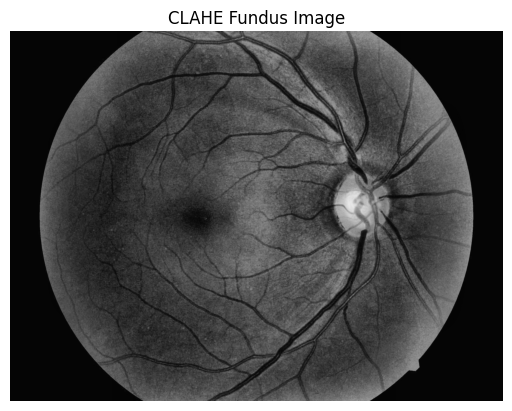

In [7]:
image_path = "inferior (4).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


In [8]:
predictor.set_image(image_rgb)


In [11]:
# Example values – CHANGE based on your image
x1, y1 = 200, 150   # top-left corner
x2, y2 = 450, 400   # bottom-right corner

box = np.array([x1, y1, x2, y2])



In [12]:
masks, scores, logits = predictor.predict(
    box=box,
    multimask_output=True
)


In [13]:
print(image_rgb.shape)


(1920, 2560, 3)


In [ ]:
import cv2
import numpy as np

# 1️⃣ Load image
image = cv2.imread("inferior (4).jpg")   # ← put correct image path

# Check if image loaded
if image is None:
    raise ValueError("Image not found. Check path.")

# 2️⃣ Copy image for ROI selection
img = image.copy()

# 3️⃣ Select bounding box
bbox = cv2.selectROI("Select RNFL region", img, False)
cv2.destroyAllWindows()

# 4️⃣ Convert ROI to SAM box format
x, y, w, h = bbox
box = np.array([x, y, x + w, y + h])
